# Reconocimiento de Acciones con Red TSM





## Instrucciones Generales

El siguiente práctico se debe realizar de forma **individual**. El formato de entregar es el **archivo .ipynb con todas las celdas ejecutadas**. Todas las preguntas deben ser respondida en celdas de texto. No se aceptará el _output_ de una celda de código como respuesta.

**Nombre compañero 1:** Vicente Zapata

**Fecha de entrega: .**

El siguiente práctico cuanta con 1 secciones donde cada una contendrá 1 o más actividades a realizar. Algunas actividades correspondrán a escribir código y otras a responder preguntas.

El practico debe entregarse de forma **Individual** en caso contrario obtendrán la mínima calificación (1). Asimismo, debe indicar su nombre donde se indica sino la práctica no será calificada.

## Consejo : se debe ejecutar primero la descarga del dataset (paso 4)

---



## 1.0 Introduction

El objetivo del reconocimiento de actividades humanas es examinar actividades a partir de secuencias de video o imágenes fijas. Uno de los modelos más importantes en esta área está descrito en el documento. "[TSM: Temporal Shift Module for Efficient Video Understanding](https://arxiv.org/pdf/1811.08383.pdf)" by Ji Lin, Chuang Gan, Son Han. The paper was published as a ICCV 2019 conference paper.

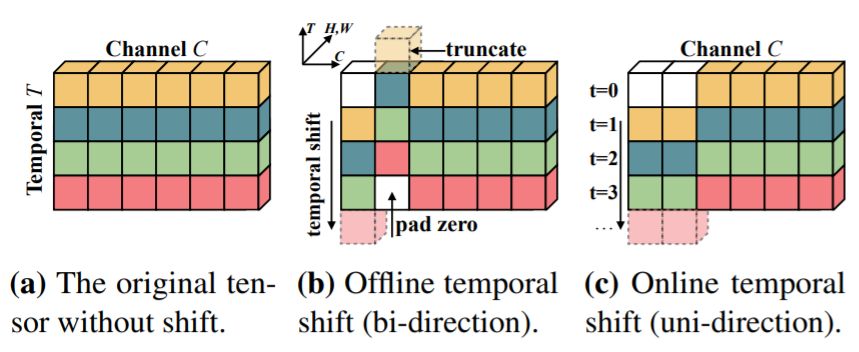


## 2.0 Setup

Este tutorial se basa en el repositorio oficial de TSM. Esta línea clona este repositorio.

In [1]:
! git clone https://github.com/mit-han-lab/temporal-shift-module.git

import os
os.chdir("/content/temporal-shift-module")

Cloning into 'temporal-shift-module'...
remote: Enumerating objects: 249, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 249 (delta 11), reused 17 (delta 9), pack-reused 226 (from 1)
Receiving objects: 100% (249/249), 253.17 KiB | 8.44 MiB/s, done.
Resolving deltas: 100% (114/114), done.


Necesitamos descargar los modelos pre-entrenados

In [2]:
!wget https://hanlab18.mit.edu/projects/tsm/models/TSM_kinetics_RGB_resnet50_shift8_blockres_avg_segment8_e100_dense.pth

--2026-05-10 23:44:27--  https://hanlab18.mit.edu/projects/tsm/models/TSM_kinetics_RGB_resnet50_shift8_blockres_avg_segment8_e100_dense.pth
Resolving hanlab18.mit.edu (hanlab18.mit.edu)... 18.25.16.171
Connecting to hanlab18.mit.edu (hanlab18.mit.edu)|18.25.16.171|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 97590233 (93M) [application/octet-stream]
Saving to: ‘TSM_kinetics_RGB_resnet50_shift8_blockres_avg_segment8_e100_dense.pth’

TSM_kinetics_RGB_re 100%[===================>]  93.07M  35.8MB/s    in 2.6s    

2026-05-10 23:44:30 (35.8 MB/s) - ‘TSM_kinetics_RGB_resnet50_shift8_blockres_avg_segment8_e100_dense.pth’ saved [97590233/97590233]



Inicializa las dependencias para este tutorial.

In [3]:
!pip install -q git+https://github.com/tensorflow/docs

  Preparing metadata (setup.py) ... done


In [4]:
import argparse
import time

import torch.nn.parallel
import torch.optim
from sklearn.metrics import confusion_matrix
from ops.dataset import TSNDataSet
from ops.models import TSN
from ops.transforms import *
from ops import dataset_config
from torch.nn import functional as F

import tempfile, ssl, re
from urllib import request  # requires python3
import subprocess
import cv2
import imageio
from tensorflow_docs.vis import embed
import glob

## 3.0 Intance the TSM Model

Configuración inicial para la Red TSM (proporcionada por los autores para los pesos específicos descargados).

In [5]:
args = {'weights':'/content/temporal-shift-module/TSM_kinetics_RGB_resnet50_shift8_blockres_avg_segment8_e100_dense.pth',
        'test_segments':8,
        'dense_sample':False,
        'twice_sample':False,
        'full_res':False,
        'test_crops':1,
        'coeff':None,
        'batch_size':1,
        'workers':8,
        'test_list':None,
        'csv_file':None,
        'softmax':True,
        'max_num':-1,
        'input_size':224,
        'crop_fusion_type':'avg',
        'gpus':None,
        'img_feature_dim': 256,
        'num_set_segments':1,
        'pretrain': 'imagenet'}

Esta función ayuda a determinar si el modelo pre-entrenado utiliza desplazamiento temporal o no utilizando el nombre del punto de control.

In [6]:
def parse_shift_option_from_log_name(log_name):
    if 'shift' in log_name:
        strings = log_name.split('_')
        for i, s in enumerate(strings):
            if 'shift' in s:
                break
        return True, int(strings[i].replace('shift', '')), strings[i + 1]
    else:
        return False, None, None

In [7]:
weights_list = args['weights'].split(',')
test_segments_list = [args['test_segments']]
assert len(weights_list) == len(test_segments_list)
if args['coeff'] is None:
    coeff_list = [1] * len(weights_list)
else:
    coeff_list = [float(c) for c in args['coeff'].split(',')]

if args['test_list'] is not None:
    test_file_list = args['test_list'].split(',')
else:
    test_file_list = [None] * len(weights_list)

En este caso, hay 400 clases porque el modelo fue entrenado con kinetics-400.

In [8]:
num_class = 400


Instancia el modelo TSM utilizando la configuración necesaria para los parámetros pre-entrenados.

In [9]:
data_iter_list = []
net_list = []
modality_list = []

total_num = None
for this_weights, this_test_segments, test_file in zip(weights_list, test_segments_list, test_file_list):
    is_shift, shift_div, shift_place = parse_shift_option_from_log_name(this_weights.split('/')[3])
    if 'RGB' in this_weights:
        modality = 'RGB'
    else:
        modality = 'Flow'
    this_arch = this_weights.split('TSM_')[1].split('_')[2]
    modality_list.append(modality)
    # num_class, args.train_list, val_list, root_path, prefix = dataset_config.return_dataset(args.dataset, modality)
    print('=> shift: {}, shift_div: {}, shift_place: {}'.format(is_shift, shift_div, shift_place))
    net = TSN(num_class, this_test_segments if is_shift else 1, modality,
              base_model=this_arch,
              consensus_type=args['crop_fusion_type'],
              img_feature_dim=args['img_feature_dim'],
              pretrain=args['pretrain'],
              is_shift=is_shift, shift_div=shift_div, shift_place=shift_place,
              non_local='_nl' in this_weights,
              )

=> shift: True, shift_div: 8, shift_place: blockres

    Initializing TSN with base model: resnet50.
    TSN Configurations:
        input_modality:     RGB
        num_segments:       8
        new_length:         1
        consensus_module:   avg
        dropout_ratio:      0.8
        img_feature_dim:    256
            
=> base model: resnet50


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 164MB/s]


Adding temporal shift...
=> n_segment per stage: [8, 8, 8, 8]
=> Processing stage with 3 blocks residual
=> Using fold div: 8
=> Using fold div: 8
=> Using fold div: 8
=> Processing stage with 4 blocks residual
=> Using fold div: 8
=> Using fold div: 8
=> Using fold div: 8
=> Using fold div: 8
=> Processing stage with 6 blocks residual
=> Using fold div: 8
=> Using fold div: 8
=> Using fold div: 8
=> Using fold div: 8
=> Using fold div: 8
=> Using fold div: 8
=> Processing stage with 3 blocks residual
=> Using fold div: 8
=> Using fold div: 8
=> Using fold div: 8


In [10]:
if 'tpool' in this_weights:
    from ops.temporal_shift import make_temporal_pool
    make_temporal_pool(net.base_model, this_test_segments)  # since DataParallel


Carga los parámetros pre-entrenados.

In [11]:
checkpoint = torch.load(this_weights)
checkpoint = checkpoint['state_dict']

# base_dict = {('base_model.' + k).replace('base_model.fc', 'new_fc'): v for k, v in list(checkpoint.items())}
base_dict = {'.'.join(k.split('.')[1:]): v for k, v in list(checkpoint.items())}
replace_dict = {'base_model.classifier.weight': 'new_fc.weight',
                'base_model.classifier.bias': 'new_fc.bias',
                }
for k, v in replace_dict.items():
    if k in base_dict:
        base_dict[v] = base_dict.pop(k)

net.load_state_dict(base_dict)

<All keys matched successfully>

## 4.0 Download video dataset


Las siguientes funciones permiten obtener videos del conjunto de datos UCF101 desde el repositorio original:

* **list_ucf_videos** devuelve la lista de videos.
* **fetch_ucf_video** devuelve un video seleccionado, necesitas proporcionar el nombre del video.

In [12]:
!wget --no-check-certificate https://www.crcv.ucf.edu/data/UCF101/UCF101.rar

--2026-05-10 23:45:00--  https://www.crcv.ucf.edu/data/UCF101/UCF101.rar
Resolving www.crcv.ucf.edu (www.crcv.ucf.edu)... 132.170.214.127
Connecting to www.crcv.ucf.edu (www.crcv.ucf.edu)|132.170.214.127|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 6932971618 (6.5G) [application/x-rar-compressed]
Saving to: ‘UCF101.rar’

UCF101.rar          100%[===================>]   6.46G  39.1MB/s    in 2m 31s  

2026-05-10 23:47:32 (43.8 MB/s) - ‘UCF101.rar’ saved [6932971618/6932971618]



In [13]:
!unrar x '/content/UCF101.rar'


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal

Cannot open /content/UCF101.rar
No such file or directory
No files to extract


In [14]:
# Utilities to fetch videos from UCF101 dataset
UCF_ROOT = '/content/UCF-101'
_VIDEO_LIST = None
_CACHE_DIR = '/content/data/'
# As of July 2020, crcv.ucf.edu doesn't use a certificate accepted by the
# default Colab environment anymore.
unverified_context = ssl._create_unverified_context()

def fetch_ucf_video(video):
  """Fetchs a video and cache into local filesystem."""
  cache_path = os.path.join(_CACHE_DIR, video)
  if not os.path.exists(cache_path):
    urlpath = request.urljoin(UCF_ROOT, video)
    print("Fetching %s => %s" % (urlpath, cache_path))
    data = request.urlopen(urlpath, context=unverified_context).read()
    open(cache_path, "wb").write(data)
  return cache_path

In [15]:
import os
import re
from collections import defaultdict

def list_ucf_videos(video_dir):
    """
    Lists AVI videos available in the UCF101 dataset from a specified local directory,
    including all subdirectories, and groups them by category.

    Args:
        video_dir (str): Path to the directory containing the UCF101 video files.

    Returns:
        dict: Dictionary with categories as keys and a list of video filenames as values.
        list: List of all video filenames found in all categories.
    """
    if not os.path.exists(video_dir):
        raise ValueError(f"Provided directory does not exist: {video_dir}")
    if not os.path.isdir(video_dir):
        raise ValueError(f"Provided path is not a directory: {video_dir}")

    category_videos = defaultdict(list)
    all_videos = []  # Initialize an empty list to store all video filenames
    # Walk through all subdirectories
    for root, dirs, files in os.walk(video_dir):
        category_name = os.path.basename(root)  # Get the name of the directory
        for filename in files:
            # Check if the file is an AVI video
            if re.match(r"^v_.*\.avi$", filename):
                category_videos[category_name].append(filename)
                all_videos.append(filename)  # Add filename to all_videos list

    # Sort and format the output
    for category in sorted(category_videos):
        videos = category_videos[category]
        videos.sort()
        num_videos = len(videos)
        sample_videos = ', '.join(videos[:min(3, num_videos)]) + ', ...' if num_videos > 3 else ', '.join(videos)
        print(f"{category:<20} {num_videos} videos ({sample_videos})")

    return category_videos, all_videos  # Return both the dictionary and the list of all videos



La función **to_gif** convierte un video a un archivo GIF

In [16]:
# Utilities to open video files using CV2
def crop_center_square(frame):
  y, x = frame.shape[0:2]
  min_dim = min(y, x)
  start_x = (x // 2) - (min_dim // 2)
  start_y = (y // 2) - (min_dim // 2)
  return frame[start_y:start_y+min_dim,start_x:start_x+min_dim]

def load_video(path, max_frames=0, resize=(224, 224)):
  cap = cv2.VideoCapture(path)
  frames = []
  try:
    while True:
      ret, frame = cap.read()
      if not ret:
        break
      frame = crop_center_square(frame)
      frame = cv2.resize(frame, resize)
      frame = frame[:, :, [2, 1, 0]]
      frames.append(frame)

      if len(frames) == max_frames:
        break
  finally:
    cap.release()
  return np.array(frames) / 255.0

def to_gif(path):
  images = load_video(path)
  name = path.split('/')[-1:][0].split('.')[0]
  converted_images = np.clip(images * 255, 0, 255).astype(np.uint8)
  imageio.mimsave('/content/{}.gif'.format(name), converted_images, fps=25)
  return embed.embed_file('/content/{}.gif'.format(name))

In [19]:
import os
import subprocess

# Get the list of videos in the dataset.

# Check if UCF-101 directory exists, if not, try to extract it.
if not os.path.exists(UCF_ROOT):
    rar_path = '/content/temporal-shift-module/UCF101.rar'
    if os.path.exists(rar_path):
        print(f"Attempting to extract {rar_path} to {os.path.dirname(UCF_ROOT)}")
        # Execute unrar command to extract to /content/
        try:
            # The 'x' argument extracts files with full paths.
            # The destination path should be the parent directory of UCF_ROOT, which is '/content/'
            subprocess.run(['unrar', 'x', rar_path, os.path.dirname(UCF_ROOT)], check=True)
            print("UCF-101 dataset extracted successfully.")
        except subprocess.CalledProcessError as e:
            print(f"Error during unrar extraction: {e}")
            print("Please ensure 'unrar' is installed and the RAR file is not corrupted.")
    else:
        print(f"Error: RAR file not found at {rar_path}. Please ensure UCF101.rar was downloaded correctly.")

# Now attempt to list the videos from the (now hopefully existing) UCF_ROOT.
ucf_videos = list_ucf_videos(UCF_ROOT)


Attempting to extract /content/temporal-shift-module/UCF101.rar to /content
UCF-101 dataset extracted successfully.
ApplyEyeMakeup       145 videos (v_ApplyEyeMakeup_g01_c01.avi, v_ApplyEyeMakeup_g01_c02.avi, v_ApplyEyeMakeup_g01_c03.avi, ...)
ApplyLipstick        114 videos (v_ApplyLipstick_g01_c01.avi, v_ApplyLipstick_g01_c02.avi, v_ApplyLipstick_g01_c03.avi, ...)
Archery              145 videos (v_Archery_g01_c01.avi, v_Archery_g01_c02.avi, v_Archery_g01_c03.avi, ...)
BabyCrawling         132 videos (v_BabyCrawling_g01_c01.avi, v_BabyCrawling_g01_c02.avi, v_BabyCrawling_g01_c03.avi, ...)
BalanceBeam          108 videos (v_BalanceBeam_g01_c01.avi, v_BalanceBeam_g01_c02.avi, v_BalanceBeam_g01_c03.avi, ...)
BandMarching         155 videos (v_BandMarching_g01_c01.avi, v_BandMarching_g01_c02.avi, v_BandMarching_g01_c03.avi, ...)
BaseballPitch        150 videos (v_BaseballPitch_g01_c01.avi, v_BaseballPitch_g01_c02.avi, v_BaseballPitch_g01_c03.avi, ...)
Basketball           134 videos (v_B


Crear las carpetas de datos.

In [20]:
os.mkdir('/content/data/')
os.mkdir('/content/data/videos/')

Descargar un video

In [21]:
video_path = fetch_ucf_video("/content/UCF-101/HighJump/v_HighJump_g01_c02.avi")

## 5.0 Preparar los datos

Transformación de video para la red.

In [22]:
input_size = net.scale_size if args['full_res'] else net.input_size
if args['test_crops'] == 1:
    cropping = torchvision.transforms.Compose([
        GroupScale(net.scale_size),
        GroupCenterCrop(input_size),
    ])
elif args['test_crops'] == 3:  # do not flip, so only 5 crops
    cropping = torchvision.transforms.Compose([
        GroupFullResSample(input_size, net.scale_size, flip=False)
    ])
elif args['test_crops'] == 5:  # do not flip, so only 5 crops
    cropping = torchvision.transforms.Compose([
        GroupOverSample(input_size, net.scale_size, flip=False)
    ])
elif args['test_crops'] == 10:
    cropping = torchvision.transforms.Compose([
        GroupOverSample(input_size, net.scale_size)
    ])
else:
    raise ValueError("Only 1, 5, 10 crops are supported while we got {}".format(args.test_crops))

Función para preprocesar los videos.

In [23]:
def vid2jpg(file_name, video_file_path, dst_class_path):

    name, ext = os.path.splitext(file_name)
    dst_directory_path = os.path.join(dst_class_path, name)

    try:
        if os.path.exists(dst_directory_path):
            if not os.path.exists(os.path.join(dst_directory_path, 'img_00001.jpg')):
                subprocess.call('rm -r \"{}\"'.format(dst_directory_path), shell=True)
                print('remove {}'.format(dst_directory_path))
                os.mkdir(dst_directory_path)
            else:
                print('*** convert has been done: {}'.format(dst_directory_path))
                return
        else:
            os.mkdir(dst_directory_path)
    except:
        print(dst_directory_path)
        return
    cmd = 'ffmpeg -i \"{}\" -threads 1 -vf scale=-1:331 -q:v 0 \"{}/img_%05d.jpg\"'.format(video_file_path, dst_directory_path)
    # print(cmd)
    subprocess.call(cmd, shell=True,
                    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

In [24]:
vid2jpg('v_HighJump_g01_c02.avi', '/content/UCF-101/HighJump/v_HighJump_g01_c02.avi', '/content/data/videos/')

## 6.0 Dataset

Esta es la clase de conjunto de datos que es esencial para llevar los videos al modelo.



In [25]:
# Code for "TSM: Temporal Shift Module for Efficient Video Understanding"
# arXiv:1811.08383
# Ji Lin*, Chuang Gan, Song Han
# {jilin, songhan}@mit.edu, ganchuang@csail.mit.edu

import torch.utils.data as data

from PIL import Image
import os
import numpy as np
from numpy.random import randint


class VideoRecord(object):
    def __init__(self, row):
        self._data = row

    @property
    def path(self):
        return self._data[0]

    @property
    def num_frames(self):
        return int(self._data[1])

    @property
    def label(self):
        return int(self._data[2])


class TSNDataSet(data.Dataset):
    def __init__(self, root_path,
                 num_segments=3, new_length=1, modality='RGB',
                 image_tmpl='img_{:05d}.jpg', transform=None,
                 random_shift=True, test_mode=False,
                 remove_missing=False, dense_sample=False, twice_sample=False):

        self.root_path = root_path
        self.num_segments = num_segments
        self.new_length = new_length
        self.modality = modality
        self.image_tmpl = image_tmpl
        self.transform = transform
        self.random_shift = random_shift
        self.test_mode = test_mode
        self.remove_missing = remove_missing
        self.dense_sample = dense_sample  # using dense sample as I3D
        self.twice_sample = twice_sample  # twice sample for more validation
        if self.dense_sample:
            print('=> Using dense sample for the dataset...')
        if self.twice_sample:
            print('=> Using twice sample for the dataset...')

        if self.modality == 'RGBDiff':
            self.new_length += 1  # Diff needs one more image to calculate diff

        self._parse_list()

    def _load_image(self, directory, idx):
        if self.modality == 'RGB' or self.modality == 'RGBDiff':
            try:
                return [Image.open(os.path.join(self.root_path, directory, self.image_tmpl.format(idx))).convert('RGB')]
            except Exception:
                print('error loading image:', os.path.join(self.root_path, directory, self.image_tmpl.format(idx)))
                return [Image.open(os.path.join(self.root_path, directory, self.image_tmpl.format(1))).convert('RGB')]
        elif self.modality == 'Flow':
            if self.image_tmpl == 'flow_{}_{:05d}.jpg':  # ucf
                x_img = Image.open(os.path.join(self.root_path, directory, self.image_tmpl.format('x', idx))).convert(
                    'L')
                y_img = Image.open(os.path.join(self.root_path, directory, self.image_tmpl.format('y', idx))).convert(
                    'L')
            elif self.image_tmpl == '{:06d}-{}_{:05d}.jpg':  # something v1 flow
                x_img = Image.open(os.path.join(self.root_path, '{:06d}'.format(int(directory)), self.image_tmpl.
                                                format(int(directory), 'x', idx))).convert('L')
                y_img = Image.open(os.path.join(self.root_path, '{:06d}'.format(int(directory)), self.image_tmpl.
                                                format(int(directory), 'y', idx))).convert('L')
            else:
                try:
                    # idx_skip = 1 + (idx-1)*5
                    flow = Image.open(os.path.join(self.root_path, directory, self.image_tmpl.format(idx))).convert(
                        'RGB')
                except Exception:
                    print('error loading flow file:',
                          os.path.join(self.root_path, directory, self.image_tmpl.format(idx)))
                    flow = Image.open(os.path.join(self.root_path, directory, self.image_tmpl.format(1))).convert('RGB')
                # the input flow file is RGB image with (flow_x, flow_y, blank) for each channel
                flow_x, flow_y, _ = flow.split()
                x_img = flow_x.convert('L')
                y_img = flow_y.convert('L')

            return [x_img, y_img]

    def _parse_list(self):
        # check the frame number is large >3:
        tmp = os.listdir(self.root_path)
        # if not self.test_mode or self.remove_missing:
        #     tmp = [item for item in tmp if int(item[1]) >= 3]
        path_frames = []
        num_frames = []
        for item in tmp:
            path_frame = os.path.join(self.root_path, item)
            path_frames.append(path_frame)
            num_frames.append(len(os.listdir(path_frame)))

        self.video_list = [VideoRecord([path_frames[i],num_frames[i]]) for i in range(len(tmp))]
        if self.image_tmpl == '{:06d}-{}_{:05d}.jpg':
            for v in self.video_list:
                v._data[1] = int(v._data[1]) / 2
        print('video number:%d' % (len(self.video_list)))

    def _sample_indices(self, record):
        """

        :param record: VideoRecord
        :return: list
        """
        if self.dense_sample:  # i3d dense sample
            sample_pos = max(1, 1 + record.num_frames - 64)
            t_stride = 64 // self.num_segments
            start_idx = 0 if sample_pos == 1 else np.random.randint(0, sample_pos - 1)
            offsets = [(idx * t_stride + start_idx) % record.num_frames for idx in range(self.num_segments)]
            return np.array(offsets) + 1
        else:  # normal sample
            average_duration = (record.num_frames - self.new_length + 1) // self.num_segments
            if average_duration > 0:
                offsets = np.multiply(list(range(self.num_segments)), average_duration) + randint(average_duration,
                                                                                                  size=self.num_segments)
            elif record.num_frames > self.num_segments:
                offsets = np.sort(randint(record.num_frames - self.new_length + 1, size=self.num_segments))
            else:
                offsets = np.zeros((self.num_segments,))
            return offsets + 1

    def _get_val_indices(self, record):
        if self.dense_sample:  # i3d dense sample
            sample_pos = max(1, 1 + record.num_frames - 64)
            t_stride = 64 // self.num_segments
            start_idx = 0 if sample_pos == 1 else np.random.randint(0, sample_pos - 1)
            offsets = [(idx * t_stride + start_idx) % record.num_frames for idx in range(self.num_segments)]
            return np.array(offsets) + 1
        else:
            if record.num_frames > self.num_segments + self.new_length - 1:
                tick = (record.num_frames - self.new_length + 1) / float(self.num_segments)
                offsets = np.array([int(tick / 2.0 + tick * x) for x in range(self.num_segments)])
            else:
                offsets = np.zeros((self.num_segments,))
            return offsets + 1

    def _get_test_indices(self, record):
        if self.dense_sample:
            sample_pos = max(1, 1 + record.num_frames - 64)
            t_stride = 64 // self.num_segments
            start_list = np.linspace(0, sample_pos - 1, num=10, dtype=int)
            offsets = []
            for start_idx in start_list.tolist():
                offsets += [(idx * t_stride + start_idx) % record.num_frames for idx in range(self.num_segments)]
            return np.array(offsets) + 1
        elif self.twice_sample:
            tick = (record.num_frames - self.new_length + 1) / float(self.num_segments)

            offsets = np.array([int(tick / 2.0 + tick * x) for x in range(self.num_segments)] +
                               [int(tick * x) for x in range(self.num_segments)])

            return offsets + 1
        else:
            tick = (record.num_frames - self.new_length + 1) / float(self.num_segments)
            offsets = np.array([int(tick / 2.0 + tick * x) for x in range(self.num_segments)])
            return offsets + 1

    def __getitem__(self, index):
        record = self.video_list[index]
        # check this is a legit video folder
        if self.image_tmpl == 'flow_{}_{:05d}.jpg':
            file_name = self.image_tmpl.format('x', 1)
            full_path = os.path.join(record.path, file_name)
        elif self.image_tmpl == '{:06d}-{}_{:05d}.jpg':
            file_name = self.image_tmpl.format(int(record.path), 'x', 1)
            full_path = os.path.join('{:06d}'.format(int(record.path)), file_name)
        else:
            file_name = self.image_tmpl.format(1)
            full_path = os.path.join(record.path, file_name)

        while not os.path.exists(full_path):
            print('################## Not Found:', os.path.join(record.path, file_name))
            index = np.random.randint(len(self.video_list))
            record = self.video_list[index]
            if self.image_tmpl == 'flow_{}_{:05d}.jpg':
                file_name = self.image_tmpl.format('x', 1)
                full_path = os.path.join(self.root_path, record.path, file_name)
            elif self.image_tmpl == '{:06d}-{}_{:05d}.jpg':
                file_name = self.image_tmpl.format(int(record.path), 'x', 1)
                full_path = os.path.join(self.root_path, '{:06d}'.format(int(record.path)), file_name)
            else:
                file_name = self.image_tmpl.format(1)
                full_path = os.path.join(self.root_path, record.path, file_name)

        if not self.test_mode:
            segment_indices = self._sample_indices(record) if self.random_shift else self._get_val_indices(record)
        else:
            segment_indices = self._get_test_indices(record)
        return self.get(record, segment_indices)

    def get(self, record, indices):

        images = list()
        to_image = []
        for seg_ind in indices:
            p = int(seg_ind)
            for i in range(self.new_length):
                seg_imgs = self._load_image(record.path, p)
                images.extend(seg_imgs)
                if p < record.num_frames:
                    p += 1

        process_data = self.transform(images)
        return process_data
    def __len__(self):
        return len(self.video_list)


Instanciamos el conjunto de datos y el cargador de datos.

In [26]:
dataset_test = TSNDataSet('/content/data/videos', num_segments=this_test_segments,
                       new_length=1 if modality == "RGB" else 5,
                       modality=modality,
                       image_tmpl='img_{:05d}.jpg',
                       test_mode=True,
                       remove_missing=len(weights_list) == 1,
                       transform=torchvision.transforms.Compose([
                           cropping,
                           Stack(roll=(this_arch in ['BNInception', 'InceptionV3'])),
                           ToTorchFormatTensor(div=(this_arch not in ['BNInception', 'InceptionV3'])),
                           GroupNormalize(net.input_mean, net.input_std),
                       ]), dense_sample=args['dense_sample'], twice_sample=args['twice_sample'])

data_loader = torch.utils.data.DataLoader(dataset_test, batch_size=args['batch_size'], shuffle=False, pin_memory=True)

video number:1


In [27]:
os.listdir('/content/data/videos')

['v_HighJump_g01_c02']

## 7.0 Realiza una inferencia con el modelo.



Configuramos el dispositivo (GPU si está disponible o CPU en otros casos).

In [28]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

Pon el modelo en modo de evaluación

In [29]:
net.eval()

Realiza las predicciones.

In [30]:
with torch.no_grad():
    outputs = []
    for data in data_loader:
        batch_size = args['batch_size']
        num_crop = args['test_crops']
        if args['dense_sample']:
            num_crop *= 10  # 10 clips for testing when using dense sample

        if args['twice_sample']:
            num_crop *= 2

        if modality == 'RGB':
            length = 3
        elif modality == 'Flow':
            length = 10
        elif modality == 'RGBDiff':
            length = 18
        else:
            raise ValueError("Unknown modality "+ modality)

        data_in = data.view(-1, length, data.size(2), data.size(3))
        if is_shift:
            data_in = data_in.view(batch_size * num_crop, this_test_segments, length, data_in.size(2), data_in.size(3))
        rst = net(data_in)
        rst = rst.reshape(batch_size, num_crop, -1).mean(1)

        if args['softmax']:
            # take the softmax to normalize the output to probability
            rst = F.softmax(rst, dim=1)

        rst = rst.data.cpu().numpy().copy()

        if net.is_shift:
            rst = rst.reshape(batch_size, num_class)
        else:
            rst = rst.reshape((batch_size, -1, num_class)).mean(axis=1).reshape((batch_size, num_class))

        outputs.append(rst)

## 8.0 Muestra las predicciones

In [31]:
def to_gif(path, max_frames=0, resize=(224, 224)):
    try:
        images = load_video(path, max_frames, resize)
        if images.size == 0:
            raise ValueError("No se cargaron imágenes desde el video.")

        name = os.path.basename(path).split('.')[0]
        gif_path = f'/content/{name}.gif'
        # Multiplicamos por 255 y convertimos a uint8 para guardarlo como GIF.
        converted_images = (images * 255).astype(np.uint8)
        imageio.mimsave(gif_path, converted_images, fps=25)

        # Suponiendo que embed es una función disponible para incrustar archivos.
        return embed.embed_file(gif_path)
    except Exception as e:
        print(f"Error al crear el GIF: {e}")
        return None

In [32]:
KINETICS_URL = "https://raw.githubusercontent.com/deepmind/kinetics-i3d/master/data/label_map.txt"
with request.urlopen(KINETICS_URL) as obj:
  labels = [line.decode("utf-8").strip() for line in obj.readlines()]
print("Found %d labels." % len(labels))

Found 400 labels.


In [33]:
# Asegurate que aviFilenameList tenga la carpeta correspondiente a la categoria del video
aviFilenamesList = glob.glob('/content/UCF-101/HighJump/*.avi')

In [34]:
index = 0


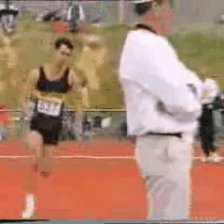

In [35]:
to_gif(aviFilenamesList[index])

In [36]:
print("Top 5 actions:")
k=5
probabilities = outputs[index].reshape(outputs[index].shape[1])
for i in np.argsort(probabilities)[::-1][:k]:
    print(f"  {labels[i]:22}: {probabilities[i] * 100:5.2f}%")

Top 5 actions:
  high jump             : 99.12%
  hurdling              :  0.86%
  pole vault            :  0.01%
  dunking basketball    :  0.00%
  long jump             :  0.00%


## 9.0 Preguntas

Ahora es tu turno. Reutiliza el código de las secciones 3, 4, 5, 6 y 7 para descargar y predecir la acción del siguiente video: **v_PlayingGuitar_g01_c01.avi**

---
##  Explicación Actividad Código — Predicción con `v_PlayingGuitar_g01_c01.avi`

El objetivo es repetir exactamente el mismo proceso que hicimos para el video de **HighJump**, pero ahora con un video de **tocar guitarra**. Repasemos los pasos:

### Pipeline completo (secciones 3→7 reutilizadas)

```
Video .avi
  ↓ PASO 1: vid2jpg()      → Convierte el video a N imágenes JPG en disco
  ↓ PASO 2: TSNDataSet()   → Carga las imágenes y las transforma (resize, crop, normalización)
  ↓ PASO 3: DataLoader     → Agrupa las imágenes en batches para el modelo
  ↓ PASO 4: net(data_in)   → El modelo TSM procesa las imágenes y predice las probabilidades
  ↓ PASO 5: argsort()      → Ordenamos las probabilidades y mostramos las top-5 clases
```

### ¿Por qué limpiamos la carpeta de videos antes?

El `TSNDataSet` carga **todos** los videos que están dentro de `/content/data/videos/`. Si dejamos el video de HighJump del paso anterior, el dataset tendrá 2 videos y `outputs[0]` podría no corresponder a la guitarra. Para estar seguros, limpiamos y ponemos solo el video nuevo.

### ¿Qué esperamos ver?

Si el modelo funciona bien, la predicción principal debería ser algo como **"playing guitar"** con una probabilidad alta. El modelo TSM fue entrenado en **Kinetics-400**, que incluye esa categoría, por lo que tiene buenas chances de acertar.

In [37]:
import shutil

# ─────────────────────────────────────────────────────────────────────────────
# PASO 1 — Limpiar la carpeta de videos y convertir el nuevo video a frames JPG
# ─────────────────────────────────────────────────────────────────────────────
# Primero limpiamos la carpeta para asegurarnos de que solo tengamos
# el video de guitarra (evitar confusión con el video de HighJump anterior).
if os.path.exists('/content/data/videos/'):
    shutil.rmtree('/content/data/videos/')
os.makedirs('/content/data/videos/')

# Ruta del video de guitarra dentro del dataset UCF-101 descargado
video_path_guitar = '/content/UCF-101/PlayingGuitar/v_PlayingGuitar_g01_c01.avi'

# vid2jpg convierte el video .avi en una carpeta de imágenes img_00001.jpg, img_00002.jpg, ...
# Esto es necesario porque el modelo TSM trabaja con imágenes, no con videos directamente.
vid2jpg('v_PlayingGuitar_g01_c01.avi', video_path_guitar, '/content/data/videos/')
print("✓ Video convertido a frames JPG correctamente.")

# ─────────────────────────────────────────────────────────────────────────────
# PASO 2 — Visualizar el video como GIF (opcional, para comprobar que cargó bien)
# ─────────────────────────────────────────────────────────────────────────────
# to_gif genera un GIF animado del video para que lo puedas ver directamente en Colab.
to_gif(video_path_guitar)

# ─────────────────────────────────────────────────────────────────────────────
# PASO 3 — Crear el Dataset y DataLoader
# ─────────────────────────────────────────────────────────────────────────────
# TSNDataSet carga los frames JPG que acabamos de generar y aplica las
# transformaciones necesarias (redimensionado, crop central, normalización).
dataset_test = TSNDataSet('/content/data/videos',
                          num_segments=this_test_segments,
                          new_length=1 if modality == "RGB" else 5,
                          modality=modality,
                          image_tmpl='img_{:05d}.jpg',
                          test_mode=True,
                          remove_missing=len(weights_list) == 1,
                          transform=torchvision.transforms.Compose([
                              cropping,
                              Stack(roll=(this_arch in ['BNInception', 'InceptionV3'])),
                              ToTorchFormatTensor(div=(this_arch not in ['BNInception', 'InceptionV3'])),
                              GroupNormalize(net.input_mean, net.input_std),
                          ]),
                          dense_sample=args['dense_sample'],
                          twice_sample=args['twice_sample'])

# DataLoader agrupa los datos en batches y los prepara para enviarlos al modelo.
data_loader = torch.utils.data.DataLoader(dataset_test,
                                          batch_size=args['batch_size'],
                                          shuffle=False,
                                          pin_memory=True)
print(f"✓ Dataset creado con {len(dataset_test)} video(s).")

# ─────────────────────────────────────────────────────────────────────────────
# PASO 4 — Ejecutar el modelo (inferencia)
# ─────────────────────────────────────────────────────────────────────────────
# Ponemos el modelo en modo evaluación (desactiva dropout, batch norm, etc.)
net.eval()

# torch.no_grad() evita que PyTorch guarde los gradientes (ahorramos memoria,
# ya que no necesitamos entrenar, solo predecir).
with torch.no_grad():
    outputs = []
    for data in data_loader:
        batch_size = args['batch_size']
        num_crop = args['test_crops']

        # Si usamos dense_sample o twice_sample, se procesan más recortes del video
        if args['dense_sample']:
            num_crop *= 10
        if args['twice_sample']:
            num_crop *= 2

        # Determinamos cuántos canales tiene cada frame según la modalidad
        # RGB = 3 canales (R, G, B)
        if modality == 'RGB':
            length = 3
        elif modality == 'Flow':
            length = 10
        elif modality == 'RGBDiff':
            length = 18
        else:
            raise ValueError("Unknown modality " + modality)

        # Reorganizamos los datos para que el modelo los procese correctamente
        data_in = data.view(-1, length, data.size(2), data.size(3))
        if is_shift:
            data_in = data_in.view(batch_size * num_crop, this_test_segments,
                                   length, data_in.size(2), data_in.size(3))

        # Pasamos los datos al modelo y obtenemos las predicciones
        rst = net(data_in)

        # Promediamos las predicciones de todos los recortes del video
        rst = rst.reshape(batch_size, num_crop, -1).mean(1)

        # Aplicamos softmax para convertir las salidas en probabilidades (0 a 1)
        if args['softmax']:
            rst = F.softmax(rst, dim=1)

        rst = rst.data.cpu().numpy().copy()

        if net.is_shift:
            rst = rst.reshape(batch_size, num_class)
        else:
            rst = rst.reshape((batch_size, -1, num_class)).mean(axis=1).reshape((batch_size, num_class))

        outputs.append(rst)

print("✓ Inferencia completada.")

# ─────────────────────────────────────────────────────────────────────────────
# PASO 5 — Mostrar las 5 predicciones más probables
# ─────────────────────────────────────────────────────────────────────────────
# index = 0 porque solo hay un video en la carpeta (el de guitarra).
index = 0
k = 5  # Mostramos las 5 acciones más probables

print("\nTop 5 acciones predichas para v_PlayingGuitar_g01_c01.avi:")
print("-" * 50)
# outputs[index] contiene las probabilidades para cada una de las 400 clases de Kinetics.
# np.argsort ordena de menor a mayor, [::-1] lo invierte (mayor a menor), [:k] toma los 5 primeros.
probabilities = outputs[index].reshape(outputs[index].shape[1])
for i in np.argsort(probabilities)[::-1][:k]:
    print(f"  {labels[i]:30}: {probabilities[i] * 100:5.2f}%")

✓ Video convertido a frames JPG correctamente.
video number:1
✓ Dataset creado con 1 video(s).
✓ Inferencia completada.

Top 5 acciones predichas para v_PlayingGuitar_g01_c01.avi:
--------------------------------------------------
  playing guitar                : 40.66%
  busking                       : 24.04%
  playing clarinet              : 13.03%
  strumming guitar              :  6.74%
  singing                       :  3.17%



Basado en el tutorial de la clase, responde las siquientes preguntas

1. ¿El modelo TSM es un modelo 3D o 2D? (1 pto)



**Respuesta:**

El modelo TSM es fundamentalmente un modelo **2D**.

Su idea clave es que, en lugar de usar convoluciones 3D (como hace I3D, que son muy costosas), TSM inserta un pequeño módulo de *desplazamiento temporal* dentro de una red **ResNet-2D estándar**. Esto le permite capturar información temporal entre frames **sin aumentar el costo computacional** de las convoluciones.

En otras palabras: la red base sigue siendo una CNN 2D normal (ResNet50), pero el módulo TSM hace que cada frame "vea" información de frames vecinos antes de aplicar la convolución 2D. El resultado es un comportamiento similar a 3D, con el costo de 2D.

2. ¿Cómo funciona el Módulo de Desplazamiento Temporal (TSM)? (1 pto)

**Respuesta:**

El Módulo de Desplazamiento Temporal funciona de la siguiente manera:

1. Se toma un tensor de forma `[N_frames, C_canales, H, W]`.
2. Se dividen los canales `C` en **tres grupos**:
   - **1/8 de los canales** se desplazan **hacia adelante** (el canal del frame *t-1* se "mueve" al frame *t*). Esto permite que el frame actual reciba información del frame anterior.
   - **1/8 de los canales** se desplazan **hacia atrás** (el canal del frame *t+1* se "mueve" al frame *t*). Esto permite que el frame actual reciba información del frame siguiente.
   - **Los 3/4 restantes** no se desplazan: permanecen en su frame original.
3. Después del desplazamiento, se aplica la **convolución 2D normal** de ResNet.

El resultado es que cada frame tiene acceso a contexto temporal de frames vecinos, pero **sin el costo computacional de las convoluciones 3D**. La operación de "shift" en sí misma es gratuita (solo es un reordenamiento de memoria).

3. ¿Cuál es la diferencia entre el desplazamiento en línea y el desplazamiento fuera de línea? (1 pto)

**Respuesta:**

| Característica | Desplazamiento **en línea** (online) | Desplazamiento **fuera de línea** (offline) |
|---|---|---|
| **Frames disponibles** | Solo frames **pasados** (t-1, t-2…) | Frames pasados **y futuros** (t-1 y t+1) |
| **Dirección del shift** | Solo hacia adelante (pasado → presente) | Bidireccional (pasado y futuro) |
| **Caso de uso** | Aplicaciones en **tiempo real** (cámara en vivo) | Procesamiento de videos **ya grabados** |
| **Precisión** | Ligeramente menor (sin contexto futuro) | Mayor precisión (contexto completo) |
| **Ejemplo práctico** | Detección de caídas en streaming | Clasificación de videos de YouTube |

**Resumen:** el desplazamiento **fuera de línea** es más preciso porque puede usar contexto del pasado y del futuro, pero requiere tener el video completo disponible. El desplazamiento **en línea** solo usa el pasado y es apropiado para sistemas en tiempo real donde los frames futuros aún no existen.

4. ¿Qué propone el TSN? (1 pto)

**Respuesta:**

**TSN (Temporal Segment Networks)** propone una estrategia de **muestreo temporal disperso** para el reconocimiento de acciones en video. Sus ideas principales son:

1. **División en segmentos**: Divide el video completo en *K* segmentos de igual duración (ej: 8 segmentos).
2. **Muestreo aleatorio por segmento**: Durante el entrenamiento, selecciona **1 frame al azar** dentro de cada segmento. Esto es mucho más eficiente que procesar todos los frames del video.
3. **Función de consenso**: Las predicciones de todos los segmentos se combinan con una función de agregación (generalmente **promedio**) para obtener la predicción final del video completo.
4. **Modelado de largo alcance temporal**: Al cubrir todo el video con segmentos distribuidos, TSN captura qué sucede al inicio, en el medio y al final del video. Esto es algo que redes que solo procesan clips cortos (como 16 frames seguidos) no pueden hacer.

TSM adopta exactamente esta misma estrategia de TSN para su pipeline de datos, por eso el dataset usa `num_segments=8`.

5. ¿Cuáles son las diferencias entre el muestreo por segmentos y el muestreo uniforme? (1 pto)

**Respuesta:**

| Característica | **Muestreo por segmentos** | **Muestreo uniforme** |
|---|---|---|
| **Cómo funciona** | Divide el video en K segmentos; elige 1 frame por segmento | Selecciona N frames a intervalos fijos y regulares |
| **Aleatoriedad** | Aleatorio durante entrenamiento | Fijo y determinístico (siempre los mismos frames) |
| **Cobertura temporal** | Garantiza cobertura de todo el video | También cubre todo, pero en posiciones siempre fijas |
| **Robustez al entrenamiento** | Más variedad → mejor generalización | Sin variedad → puede sobreajustarse |
| **Uso típico** | Entrenamiento con TSN/TSM | Evaluación/inferencia en test |

**Ejemplo con un video de 100 frames y K=4:**

```
Muestreo por segmentos (entrenamiento):
  Segmento 1 [frames  1-25]:  → elige frame 13 (aleatorio dentro del segmento)
  Segmento 2 [frames 26-50]:  → elige frame 31 (aleatorio)
  Segmento 3 [frames 51-75]:  → elige frame 68 (aleatorio)
  Segmento 4 [frames 76-100]: → elige frame 89 (aleatorio)

Muestreo uniforme:
  → Frames fijos: 12, 37, 62, 87 (calculados como centro de cada cuarto, siempre iguales)
```

**Resumen:** el muestreo por segmentos aporta **variedad aleatoria** durante el entrenamiento (funciona como *data augmentation* temporal), mientras que el muestreo uniforme es predecible y reproducible, ideal para la evaluación final.